# 03 - Stage 1 Pre-training (Colab A100)
Run masked generative pre-training for REACT.

## Setup Instructions
Before running this notebook:
1. Upload your data zip to Google Drive at: `MyDrive/CiteMind/data.zip`
   - Zip locally (PowerShell): `Compress-Archive -Path src\data -DestinationPath audiocite_data.zip`
2. Set runtime to **A100 GPU**: Runtime → Change runtime type → A100 GPU
3. Run all cells in order

In [1]:
# ── Step 1: Mount Google Drive ──────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/CiteMind'
DATA_ZIP  = f'{DRIVE_DIR}/data.zip'
CKPT_DIR  = f'{DRIVE_DIR}/checkpoints/pretrain'

import os
os.makedirs(DRIVE_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)
print('Drive mounted.')
print(f'Expected data zip: {DATA_ZIP}')

Mounted at /content/drive
Drive mounted.
Expected data zip: /content/drive/MyDrive/CiteMind/data.zip


In [2]:
# ── Step 2: Clone repo ──────────────────────────────────────────────────
import os
if not os.path.exists('/content/repo'):
    !git clone https://github.com/mohamedzait20003/ECE595NLP-Project /content/repo
else:
    !git -C /content/repo pull origin main
%cd /content/repo
print('Repo ready.')

Cloning into '/content/repo'...
remote: Enumerating objects: 195, done.
remote: Counting objects: 100% (195/195), done.
remote: Compressing objects: 100% (135/135), done.
remote: Total 195 (delta 107), reused 134 (delta 53), pack-reused 0 (from 0)
Receiving objects: 100% (195/195), 6.95 MiB | 12.32 MiB/s, done.
Resolving deltas: 100% (107/107), done.
/content/repo
Repo ready.


In [3]:
# ── Step 3: Install dependencies ────────────────────────────────────────
!pip install -q -r requirements.txt
!pip install -q torch --index-url https://download.pytorch.org/whl/cu124
print('Dependencies installed.')

Dependencies installed.


In [4]:
# ── Step 4: Extract data from Drive ─────────────────────────────────────
import os, json, re
from pathlib import Path

if not os.path.exists(DATA_ZIP):
    raise FileNotFoundError(
        f'Data zip not found at {DATA_ZIP}\n'
        'Please upload data.zip to MyDrive/CiteMind/ in Google Drive.'
    )

print(f'Found: {DATA_ZIP}')
# Extract directly into src/ so data/ lands at src/data/
!unzip -q -o "{DATA_ZIP}" -d /content/repo/src/data
print('Zip extracted.')

# Patch Windows absolute paths in manifest JSON files → Colab paths
AUDIO_BASE = '/content/repo/src/data/audio'
target = Path('/content/repo/src/data')

for manifest_name in ['train_manifest.json', 'val_manifest.json', 'test_manifest.json']:
    manifest_path = target / 'audio' / manifest_name
    if not manifest_path.exists():
        continue
    with open(manifest_path, 'r', encoding='utf-8') as f:
        entries = json.load(f)
    patched = 0
    for entry in entries:
        ap = entry.get('audio_path', '')
        if not ap.startswith('/content'):
            parts = re.split(r'[/\\]', ap)
            fname  = parts[-1]
            subdir = parts[-2] if len(parts) >= 2 else manifest_name.split('_')[0]
            entry['audio_path'] = f'{AUDIO_BASE}/{subdir}/{fname}'
            patched += 1
    with open(manifest_path, 'w', encoding='utf-8') as f:
        json.dump(entries, f)
    print(f'  Patched {patched} paths in {manifest_name}')

# Verify
print()
for f in ['src/data/audio/train_manifest.json',
          'src/data/audio/val_manifest.json',
          'src/data/processed/train.json']:
    status = 'OK' if os.path.exists(f'/content/repo/{f}') else 'MISSING'
    print(f'  [{status}]  {f}')

Found: /content/drive/MyDrive/CiteMind/data.zip
Zip extracted.
  Patched 15211 paths in train_manifest.json
  Patched 1901 paths in val_manifest.json
  Patched 1902 paths in test_manifest.json

  [OK]  src/data/audio/train_manifest.json
  [OK]  src/data/audio/val_manifest.json
  [OK]  src/data/processed/train.json


In [5]:
# ── Step 5: Verify GPU ──────────────────────────────────────────────────
import sys
import torch

sys.path.insert(0, '/content/repo')

assert torch.cuda.is_available(), 'No GPU found! Set runtime to A100.'
print(f'Device : {torch.cuda.get_device_name(0)}')
print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device : NVIDIA A100-SXM4-40GB
VRAM   : 42.4 GB


In [6]:
# ── Step 6: Configure training (A100 optimized) ─────────────────────────
import yaml
from pathlib import Path

config_path = Path('/content/repo/src/config/pretrain_config.yaml')

with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

# Only override hardware-specific settings — leave all other values as defined in the config file
config['training']['fp16'] = True
config['training']['batch_size'] = 8
config['training']['gradient_accumulation_steps'] = 4
config['training']['checkpoint_dir'] = CKPT_DIR
config['data']['num_workers'] = 4

with open(config_path, 'w') as f:
    yaml.dump(config, f)

print('Config (A100):')
print(f"  total_steps      : {config['training']['total_steps']}")
print(f"  batch_size       : {config['training']['batch_size']}")
print(f"  effective_batch  : {config['training']['batch_size'] * config['training']['gradient_accumulation_steps']}")
print(f"  warmup_steps     : {config['training']['warmup_steps']}")
print(f"  learning_rate    : {config['training']['learning_rate']}")
print(f"  fp16             : {config['training']['fp16']}")
print(f"  checkpoint       : {config['training']['checkpoint_dir']}")

Config (A100):
  total_steps      : 15000
  batch_size       : 8
  effective_batch  : 32
  warmup_steps     : 500
  learning_rate    : 5e-05
  fp16             : True
  checkpoint       : /content/drive/MyDrive/CiteMind/checkpoints/pretrain


In [7]:
# ── Step 7: Run training ────────────────────────────────────────────────
from src.main.training import train
train(str(config_path))

Using device: cuda
Loading Model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

...

  Step  14950 | loss: 1.9521 | lr: 3.89e-05


Pre-training: 100%|██████████| 15000/15000 [40:46<00:00,  7.92step/s, loss=1.5570, lr=3.88e-05]

  Step  15000 | loss: 1.5570 | lr: 3.88e-05

  [Eval] Step 15000 | val_loss: 2.0915  ← best so far, saved checkpoint


Pre-training: 100%|██████████| 15000/15000 [41:08<00:00,  6.08step/s, loss=1.5570, lr=3.88e-05]



Training log saved to /content/drive/MyDrive/CiteMind/checkpoints/pretrain/training_log.json

Stage 1 complete. Best val loss: 2.0915
Checkpoints saved to: /content/drive/MyDrive/CiteMind/checkpoints/pretrain


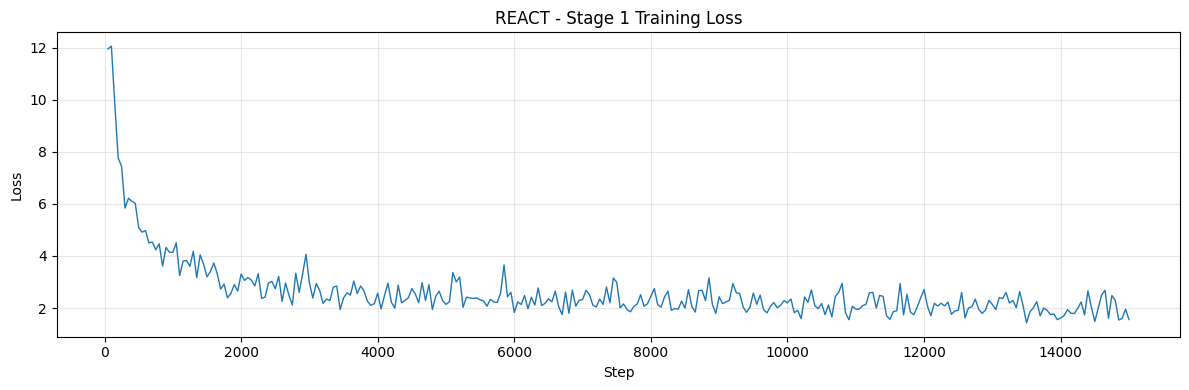

Final loss : 1.5570
Best  loss : 1.4281


In [8]:
# ── Step 8: Plot training loss ──────────────────────────────────────────
import json
import matplotlib.pyplot as plt

log_path = Path(CKPT_DIR) / 'training_log.json'

with open(log_path, 'r') as f:
    history = json.load(f)

steps  = [h['step'] for h in history]
losses = [h['train_loss'] for h in history]

plt.figure(figsize=(12, 4))
plt.plot(steps, losses, linewidth=1)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('REACT - Stage 1 Training Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f'Final loss : {losses[-1]:.4f}')
print(f'Best  loss : {min(losses):.4f}')

In [12]:
!git -C /content/repo pull origin main

remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 6 (delta 5), reused 6 (delta 5), pack-reused 0 (from 0)
Unpacking objects: 100% (6/6), 503 bytes | 503.00 KiB/s, done.
From https://github.com/mohamedzait20003/ECE595NLP-Project
 * branch            main       -> FETCH_HEAD
   35f82aa..d03e68b  main       -> origin/main
Updating 35f82aa..d03e68b
Fast-forward
 src/main/model/main_model.py | 9 ++-------
 1 file changed, 2 insertions(+), 7 deletions(-)


In [ ]:
# ── Step 9: Sanity check on best checkpoint ─────────────────────────────
import torch
from pathlib import Path
from src.main.model.main_model import MainModel
from transformers import BartTokenizer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

ckpt_path = Path(CKPT_DIR) / 'checkpoint_best.pt'
ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
print(f'Best checkpoint — step: {ckpt["step"]} | val_loss: {ckpt["val_loss"]:.4f}')

model = MainModel(
    whispher_model='openai/whisper-small',
    bart_model='facebook/bart-base'
).to(device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

tokenizer = BartTokenizer.from_pretrained('facebook/bart-base')

ctx = 'A Survey on Natural Language Processing with Deep Learning'
enc = tokenizer(ctx, return_tensors='pt', max_length=128, truncation=True)

dummy_audio = torch.randn(1, 80, 3000).to(device)
text_ids    = enc['input_ids'].to(device)
text_mask   = enc['attention_mask'].to(device)

with torch.no_grad():
    out = model.generate(
        audio_features=dummy_audio,
        text_input_ids=text_ids,
        text_attention_mask=text_mask,
        max_length=32,
        num_beams=3,
    )

print('Generated:', tokenizer.decode(out[0], skip_special_tokens=True))
print('Checkpoints saved to Google Drive at:', CKPT_DIR)